In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [ ]:
data = yf.download(
    "^NSEI",
    start="2025-01-01",
    end="2025-12-31"
)
close = data["Close"];
close.head()

In [ ]:
ln_returns = np.log(close/close.shift(1)).dropna();

ln_returns

In [ ]:
log_returns = np.log(data["Close"] / data["Close"].shift(1))
# print(log_returns)
c2c_vol = log_returns.std() * np.sqrt(252)

print("C2C volatility : ",c2c_vol);

In [ ]:
N = len(data)

parkinson_vol = np.sqrt(
    (252 / (4 * N * np.log(2))) *
    np.sum(np.log(data["High"] / data["Low"]) ** 2)
)

print("Parkinson volatility : ",parkinson_vol)

In [ ]:
gk_variance = (
    0.5 * np.log(data["High"] / data["Low"])**2
    - (2 * np.log(2) - 1)
    * np.log(data["Close"] / data["Open"])**2
).mean()

gk_vol = np.sqrt(gk_variance * 252)

print("German Klass : ",gk_vol);

In [ ]:
test_data = yf.download(
    "^NSEI",
    start="2026-01-01",
    end="2026-08-01"
)

returns = ln_returns * 100


In [ ]:
from arch import arch_model

model = arch_model(
    returns,
    mean="Constant",
    vol="GARCH",
    p=1,
    o=1,
    q=1,
    power=2
)

result = model.fit()

print(result.summary())

In [ ]:
horizon = len(test_data.loc["2026-01-01":"2026-08-01"])

forecast = result.forecast(horizon=horizon)

annualized_vol = (
    np.sqrt(forecast.variance.iloc[-1]) / 100
) * np.sqrt(252)

print(annualized_vol)

In [ ]:
test_log_returns = np.log(test_data["Close"] / test_data["Close"].shift(1))

test_c2c_vol = test_log_returns.rolling(window=15).std()*np.sqrt(252);

print(test_c2c_vol)


In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(test_data.index, test_c2c_vol, label="C2C Realized Volatility")
plt.plot(test_data.index, annualized_vol, label="TGARCH Predicted Volatility")

plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.title("C2C Realized vs TGARCH Predicted Volatility")

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
predicted_vol = []

# create full return series including test period
full_data = pd.concat([data, test_data])

full_returns = np.log(
    full_data["Close"] / full_data["Close"].shift(1)
).dropna()


window = len(ln_returns)   # your 2025 training size


for i in range(len(test_data)):

    # rolling window
    train_returns = full_returns.iloc[i:i+window] * 100

    model = arch_model(
        train_returns,
        mean="Constant",
        vol="GARCH",
        p=1,
        o=1,
        q=1,
        power=2,
        dist="t"
    )

    result = model.fit(disp="off")
    
    forecast = result.forecast(horizon=1)
    
    variance = forecast.variance.iloc[-1,0]

    volatility = (
        np.sqrt(variance) / 100
    ) * np.sqrt(252)

    predicted_vol.append(volatility)

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(test_data.index, test_c2c_vol, label="C2C Realized Volatility")
plt.plot(test_data.index, predicted_vol, label="Recurring TGARCH Predicted Volatility")

plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.title("C2C Realized vs TGARCH Predicted Volatility")

plt.legend()
plt.grid(True)
plt.show()


NOW, what ill do is like get the several n-week volatilities, and then do a recurring linear regression on them to predict the volatilities

In [147]:
windows = {
    "6_week_vol": 6 * 5,
    "12_week_vol": 12 * 5,
    "24_week_vol": 24 * 5,
    "30_week_vol": 30 * 5,
    "40_week_vol": 40 * 5,
    "52_week_vol": 52 * 5
}

historical_vol = {}

for name, days in windows.items():

    last_returns = ln_returns.iloc[-days:]

    vol = last_returns.std() * np.sqrt(252)

    historical_vol[name] = vol


historical_vol = np.array(list(historical_vol.values()))

historical_vol.flatten()

array([0.07731602, 0.07481065, 0.08027105, 0.08270509, 0.11575008,
       0.11814051])

In [148]:
def weighted_vol_forecast(days):

    if days <= 30:          # <=6 weeks
        weights = np.array([
            0.50, 0.25, 0.15, 0.05, 0.03, 0.02
        ])

    elif days <= 60:        # 6-12 weeks
        weights = np.array([
            0.35, 0.35, 0.15, 0.07, 0.05, 0.03
        ])

    elif days <= 120:       # 12-24 weeks
        weights = np.array([
            0.20, 0.30, 0.30, 0.10, 0.07, 0.03
        ])

    else:                   # >24 weeks
        weights = np.array([
            0.10, 0.20, 0.25, 0.20, 0.15, 0.10
        ])

    return np.sum(weights * historical_vol)

In [153]:
historical_vol = historical_vol.flatten()

predicted_vol1 = []

for day in range(1, len(test_data)+1):
    predicted_vol1.append(
        weighted_vol_forecast(day)
    )

predicted_vol1 = np.array(predicted_vol1)

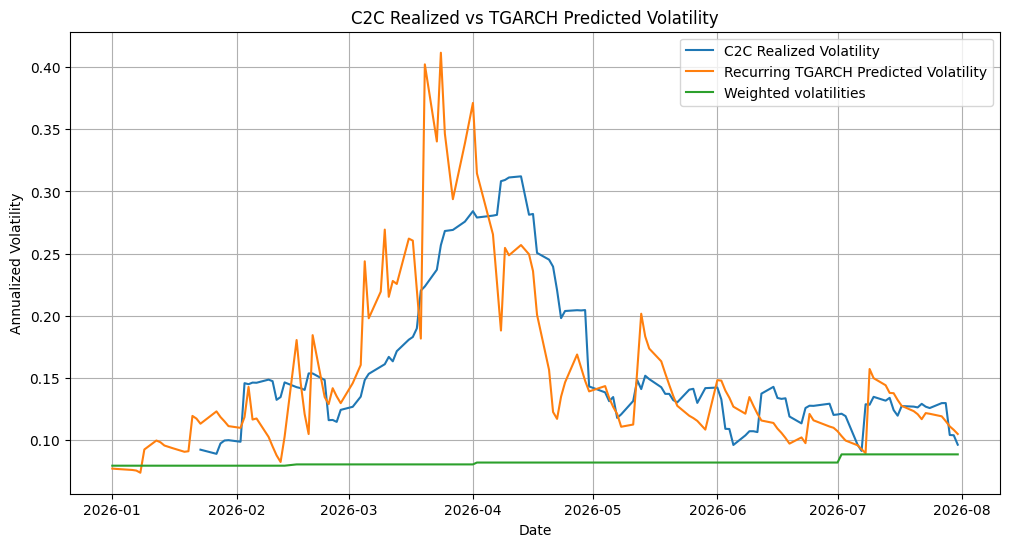

In [154]:
plt.figure(figsize=(12, 6))

plt.plot(test_data.index, test_c2c_vol, label="C2C Realized Volatility")
plt.plot(test_data.index, predicted_vol, label="Recurring TGARCH Predicted Volatility")
plt.plot(test_data.index,predicted_vol1, label = "Weighted volatilities")

plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.title("C2C Realized vs TGARCH Predicted Volatility")

plt.legend()
plt.grid(True)
plt.show()